# 07 - Análisis de Datos con Python: un mini pipeline Medallion

**Encuentro 5 — Procesamiento Digital de Imágenes (IFTS24 / UTN)**

Caso de estudio: **producción agrícola argentina**, con **datos reales y oficiales**.

Usamos las **Estimaciones Agrícolas del MAGyP** (Ministerio de Agricultura,
Ganadería y Pesca): superficie sembrada y cosechada, producción y rendimiento por
cultivo, campaña, provincia y departamento. Es la misma serie que cruza la Bolsa
de Cereales, pero publicada como **datos abiertos** descargables.

> 📂 Fuente: <https://datos.magyp.gob.ar/dataset/estimaciones-agricolas>

Llevamos esos datos, **en un solo proceso**, desde el crudo hasta información
lista para decidir, usando la **arquitectura Medallion**: tres capas
(`unprocessed` → `processed` → `curated`) donde cada una lee de la anterior y
**guarda su resultado en disco**.

## Objetivo

Recorrer el flujo profesional de datos viendo en cada capa **qué entra, qué sale
y por qué**:

1. **Capa `unprocessed`** — ingestar y *explorar* el dato crudo (sin tocarlo).
2. **Capa `processed`** — *limpiar y transformar*: consolidar cultivos (evitando
   doble conteo), pasar rendimiento de kg/ha a tn/ha y tratar las pérdidas de
   cosecha (que aparecen como ceros).
3. **Capa `curated`** — *agregar* a nivel negocio: resúmenes y series listas.
4. **Análisis y visualización** — responder preguntas con estadística y gráficos.

## Terminología clave (Microglosario)

| Término | Significado |
|---|---|
| **DataFrame** | Tabla bidimensional de Pandas (filas × columnas). |
| **dtype** | Tipo de dato de una columna (`int64`, `float64`, `object`). |
| **campaña** | Ciclo agrícola, identificado por dos años (ej. `2023/2024`). |
| **rendimiento** | Producción por unidad de superficie (acá tn/ha tras limpiar). |
| **groupby** | Agrupar filas por una clave para calcular agregados. |
| **pivot_table** | Tabla dinámica que resume datos cruzando filas y columnas. |
| **doble conteo** | Sumar filas que ya están agregadas en otra (ej. `soja 1ra` + `soja total`). |
| **Medallion** | Patrón de capas Bronze→Silver→Gold para refinar datos por etapas. |
| **Idempotente** | Que se puede re-ejecutar y da siempre el mismo resultado. |

## ¿Qué es la arquitectura Medallion?

Es una forma de organizar el procesamiento en **capas de calidad creciente**.
Cada capa tiene un único propósito y persiste su salida.

| Capa (estándar) | Carpeta que usamos | Qué contiene | Analogía agro 🌾 |
|---|---|---|---|
| 🥉 **Bronze** | `unprocessed/` | Dato crudo, tal como llega. **No se modifica.** | Grano recién cosechado, con tierra y piedritas |
| 🥈 **Silver** | `processed/` | Limpio, tipado, consolidado, confiable. | Grano limpio y clasificado |
| 🥇 **Gold** | `curated/` | Agregados de negocio, listos para decidir. | Informe final para el productor |

```
  Fuente: MAGyP (datos abiertos)
        │  descarga + acota
        ▼
 ┌──────────────┐    leer/explorar    ┌──────────────┐    agregar     ┌──────────────┐
 │ unprocessed  │ ──────────────────▶ │  processed   │ ─────────────▶ │   curated    │
 │  (Bronze)    │      limpiar        │   (Silver)   │                │   (Gold)     │
 └──────────────┘                     └──────────────┘                └──────────────┘
   crudo, real                         limpio, confiable               resúmenes, KPIs
```

> **Idea central:** el dato *sube de calidad* a medida que avanza de capa, y cada
> capa queda guardada. Eso diferencia un pipeline de un simple script.

## Configuración del entorno

Cargamos librerías y definimos las rutas de las tres capas. Si falta alguna
librería: `pip install pandas numpy matplotlib seaborn`.

In [ ]:
import subprocess
import warnings
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
warnings.filterwarnings("ignore", category=FutureWarning)

# Rutas del pipeline Medallion. Creamos las carpetas si no existen.
DATA = Path("data")
UNPROCESSED = DATA / "unprocessed"   # Bronze: crudo
PROCESSED = DATA / "processed"       # Silver: limpio
CURATED = DATA / "curated"           # Gold: negocio
DB_SQLITE = DATA / "agro_medallion.sqlite"
for carpeta in (UNPROCESSED, PROCESSED, CURATED):
    carpeta.mkdir(parents=True, exist_ok=True)

print("✓ Librerías cargadas | pandas", pd.__version__, "| numpy", np.__version__)
print("✓ Capas:", UNPROCESSED, "→", PROCESSED, "→", CURATED)
print("✓ SQLite:", DB_SQLITE)

✓ Librerías cargadas | pandas 3.0.3 | numpy 2.5.0
✓ Capas: data/unprocessed → data/processed → data/curated


# 🥉 Capa 1 — `unprocessed` (Bronze): ingesta y exploración

**Propósito:** traer el dato *tal cual lo publica el MAGyP* y entenderlo. Acá
**no se limpia nada**. La regla de oro del Bronze es: *el crudo es sagrado.*

### Ingesta: leer el dato crudo (lo descarga la fuente si no está)

In [ ]:
ARCHIVO_BRONZE = UNPROCESSED / "cosecha_agro.csv"

# Red de seguridad: si no está el subset, lo descargamos del MAGyP (requiere internet).
if not ARCHIVO_BRONZE.exists():
    subprocess.run(["python", "data/descargar_dataset_agro.py"], check=True)

bronze = pd.read_csv(ARCHIVO_BRONZE)
print(f"✓ Ingestado desde {ARCHIVO_BRONZE}: {bronze.shape[0]:,} filas, {bronze.shape[1]} columnas")
bronze.head()

✓ Ingestado desde data/unprocessed/cosecha_agro.csv: 15,396 filas, 11 columnas


,cultivo,anio,campania,provincia,provincia_id,departamento,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha
0,girasol,2015,2015/2016,Chaco,22.0,Libertador General San Martín,22084.0,295,295,502,1702
1,girasol,2015,2015/2016,Santa Fe,82.0,San Cristóbal,82091.0,15000,15000,33000,2200
2,girasol,2015,2015/2016,Buenos Aires,6.0,Carlos Casares,6147.0,9850,9850,23640,2400
3,girasol,2015,2015/2016,Santa Fe,82.0,General López,82042.0,450,450,1260,2800
4,girasol,2015,2015/2016,Santa Fe,82.0,San Javier,82098.0,4000,4000,5600,1400


### Exploración: ¿qué tiene y qué problemas trae el crudo?

In [ ]:
bronze.info()

<class 'pandas.DataFrame'>
RangeIndex: 15396 entries, 0 to 15395
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cultivo                  15396 non-null  str    
 1   anio                     15396 non-null  int64  
 2   campania                 15396 non-null  str    
 3   provincia                15396 non-null  str    
 4   provincia_id             15396 non-null  float64
 5   departamento             15396 non-null  str    
 6   departamento_id          15396 non-null  float64
 7   superficie_sembrada_ha   15396 non-null  int64  
 8   superficie_cosechada_ha  15396 non-null  int64  
 9   produccion_tm            15396 non-null  int64  
 10  rendimiento_kgxha        15396 non-null  int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 1.3 MB


In [4]:
# Las columnas categóricas y el rango temporal.
print("Cultivos crudos (¡ojo con las variantes!):")
print(bronze["cultivo"].value_counts())
print("\nProvincias:", bronze["provincia"].nunique(), "| Campañas:",
      sorted(bronze["campania"].unique()))

Cultivos crudos (¡ojo con las variantes!):
cultivo
maíz             2919
soja total       2746
soja 1ra         2731
trigo total      2471
soja 2da         2260
girasol          1802
trigo candeal     467
Name: count, dtype: int64

Provincias: 15 | Campañas: ['2015/2016', '2016/2017', '2017/2018', '2018/2019', '2019/2020', '2020/2021', '2021/2022', '2022/2023', '2023/2024', '2024/2025']


In [5]:
# Señales de problemas a resolver en Silver.
print("Rendimiento crudo: viene en kg/ha (ej. soja ~2600, maíz ~6300).")
print(bronze["rendimiento_kgxha"].describe()[["min", "mean", "max"]].round(0).to_string())

ceros = (bronze["superficie_cosechada_ha"] == 0).sum()
print(f"\nFilas con cosecha = 0 (pérdida total de cultivo): {ceros}")
print("→ En esas filas el rendimiento es 0: un 'faltante disfrazado de cero'.")

Rendimiento crudo: viene en kg/ha (ej. soja ~2600, maíz ~6300).
min         0.0
mean     3174.0
max     12500.0

Filas con cosecha = 0 (pérdida total de cultivo): 68
→ En esas filas el rendimiento es 0: un 'faltante disfrazado de cero'.


**Diagnóstico.** El crudo real tiene tres problemas a resolver en la
capa siguiente:

1. **Variantes de cultivo** (`soja 1ra`, `soja 2da`, `soja total`, `trigo total`,
   `trigo candeal`, …) que, si se suman todas, producen **doble conteo**.
2. **Rendimiento en kg/ha**, que conviene pasar a **tn/ha**.
3. **Pérdidas de cosecha** (cosechada = 0) que aparecen como **rendimiento 0** y
   contaminarían los promedios.

# 🥈 Capa 2 — `processed` (Silver): limpieza y transformación

**Propósito:** convertir el crudo en un dataset **limpio, consolidado y
confiable**. Trabajamos sobre una copia del Bronze y **guardamos el resultado**.

### 2.1 Consolidar cultivos y evitar el doble conteo

El crudo trae la soja desagregada (`1ra`, `2da`) **y** ya totalizada (`total`).
Si sumáramos todo, contaríamos la soja dos veces. Nos quedamos con las filas
**ya totalizadas** y renombramos a un nombre simple y sin tildes.

In [ ]:
# Mapa de cultivos válidos -> nombre normalizado. Descarta 1ra/2da y candeal.
CULTIVOS = {"soja total": "soja", "trigo total": "trigo",
            "maíz": "maiz", "girasol": "girasol"}

silver = bronze[bronze["cultivo"].isin(CULTIVOS)].copy()
silver["cultivo"] = silver["cultivo"].map(CULTIVOS)
print(f"✓ Cultivos consolidados: {sorted(silver['cultivo'].unique())}")
print(f"  Filas: {len(bronze):,} (crudo) -> {len(silver):,} (sin variantes duplicadas)")

✓ Cultivos consolidados: ['girasol', 'maiz', 'soja', 'trigo']
  Filas: 15,396 (crudo) -> 9,938 (sin variantes duplicadas)


### 2.2 Convertir el rendimiento de kg/ha a tn/ha

In [7]:
silver["rendimiento_tn_ha"] = (silver["rendimiento_kgxha"] / 1000).round(3)
# 'produccion_tm' ya está en toneladas: la renombramos para que sea explícito.
silver = silver.rename(columns={"produccion_tm": "produccion_tn"})
print("✓ Rendimiento convertido a tn/ha:")
print(silver[["cultivo", "rendimiento_kgxha", "rendimiento_tn_ha"]].head(3).to_string(index=False))

✓ Rendimiento convertido a tn/ha:
cultivo  rendimiento_kgxha  rendimiento_tn_ha
girasol               1702              1.702
girasol               2200              2.200
girasol               2400              2.400


### 2.3 Tratar las pérdidas de cosecha (ceros que son faltantes)

Una fila con `superficie_cosechada_ha = 0` es un lote que se sembró pero **no se
cosechó** (sequía, granizo, etc.). Su rendimiento 0 no es un rinde bajo: es
*ausencia de dato*. Para no ensuciar los promedios, lo **separamos**.

In [8]:
perdidas = silver[silver["superficie_cosechada_ha"] == 0]
silver = silver[silver["superficie_cosechada_ha"] > 0].reset_index(drop=True)
print(f"✓ Filas de pérdida total separadas: {len(perdidas)}")
print(f"  Quedan {len(silver):,} filas con cosecha efectiva")

✓ Filas de pérdida total separadas: 54
  Quedan 9,884 filas con cosecha efectiva


### 2.4 Tipos, duplicados y variable derivada

In [9]:
# Tipos correctos.
silver["anio"] = silver["anio"].astype(int)

# Duplicados exactos (buena práctica, aunque la fuente suele venir limpia).
antes = len(silver)
silver = silver.drop_duplicates().reset_index(drop=True)
print(f"✓ Duplicados eliminados: {antes - len(silver)}")

# Variable derivada: proporción de lo sembrado que efectivamente se cosechó.
silver["tasa_cosecha"] = (silver["superficie_cosechada_ha"]
                          / silver["superficie_sembrada_ha"]).clip(upper=1).round(3)
print(f"  Faltantes restantes: {int(silver.isna().sum().sum())}")

✓ Duplicados eliminados: 0
  Faltantes restantes: 0


### 2.5 Persistir la capa Silver

Guardamos el dataset limpio: este archivo es el **contrato** de `processed/`.

In [ ]:
columnas = ["cultivo", "anio", "campania", "provincia", "departamento",
            "superficie_sembrada_ha", "superficie_cosechada_ha",
            "produccion_tn", "rendimiento_tn_ha", "tasa_cosecha"]
silver = silver[columnas]

ARCHIVO_SILVER = PROCESSED / "cosecha_agro_limpio.csv"
silver.to_csv(ARCHIVO_SILVER, index=False, encoding="utf-8")

with sqlite3.connect(DB_SQLITE) as conn:
    silver.to_sql("cosecha_agro_limpio", conn, if_exists="replace", index=False)
    conn.execute("DROP VIEW IF EXISTS vw_cosecha_agro_limpio")
    conn.execute("CREATE VIEW vw_cosecha_agro_limpio AS SELECT * FROM cosecha_agro_limpio")

print(f"✓ Capa Silver persistida en {ARCHIVO_SILVER}")
print(f"  {silver.shape[0]:,} filas limpias, {silver.shape[1]} columnas")
print(f"✓ Tabla y vista SQLite actualizadas en {DB_SQLITE}")
silver.head()

✓ Capa Silver persistida en data/processed/cosecha_agro_limpio.csv
  9,884 filas limpias, 10 columnas


,cultivo,anio,campania,provincia,departamento,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tn,rendimiento_tn_ha,tasa_cosecha
0,girasol,2015,2015/2016,Chaco,Libertador General San Martín,295,295,502,1.702,1.0
1,girasol,2015,2015/2016,Santa Fe,San Cristóbal,15000,15000,33000,2.200,1.0
2,girasol,2015,2015/2016,Buenos Aires,Carlos Casares,9850,9850,23640,2.400,1.0
3,girasol,2015,2015/2016,Santa Fe,General López,450,450,1260,2.800,1.0
4,girasol,2015,2015/2016,Santa Fe,San Javier,4000,4000,5600,1.400,1.0


# 🥇 Capa 3 — `curated` (Gold): agregados de negocio

**Propósito:** responder preguntas de negocio. Leemos `processed` **desde disco**
(no de memoria: así demostramos que las capas están desacopladas) y generamos
tablas resumidas. Cada una se guarda en `curated/`.

Para el rendimiento usamos el **promedio ponderado** correcto:
`rinde = producción total / superficie cosechada total` (no el promedio simple de
los rindes, que daría más peso a un departamento chico que a uno enorme).

### Leer la capa Silver desde disco

In [11]:
silver_disco = pd.read_csv(ARCHIVO_SILVER)
print(f"✓ Leído desde {ARCHIVO_SILVER}: {silver_disco.shape[0]:,} filas")

✓ Leído desde data/processed/cosecha_agro_limpio.csv: 9,884 filas


### Gold 1 — Resumen por cultivo

In [12]:
resumen_cultivo = (silver_disco.groupby("cultivo")
                     .agg(registros=("cultivo", "count"),
                          superficie_total_ha=("superficie_cosechada_ha", "sum"),
                          produccion_total_tn=("produccion_tn", "sum"))
                     .assign(rinde_ponderado_tn_ha=lambda d:
                             (d["produccion_total_tn"] / d["superficie_total_ha"]).round(2))
                     .sort_values("produccion_total_tn", ascending=False))
resumen_cultivo.to_csv(CURATED / "resumen_por_cultivo.csv")
print("✓ Guardado: curated/resumen_por_cultivo.csv")
resumen_cultivo

✓ Guardado: curated/resumen_por_cultivo.csv


,registros,superficie_total_ha,produccion_total_tn,rinde_ponderado_tn_ha
cultivo,,,,
maiz,2880,75164133,518159903,6.89
soja,2739,167055390,470343037,2.82
trigo,2465,58470413,174178630,2.98
girasol,1800,18333442,38276405,2.09


### Gold 2 — Evolución del rendimiento por campaña (serie temporal)

In [13]:
evolucion = (silver_disco.groupby(["campania", "cultivo"])
               .apply(lambda d: d["produccion_tn"].sum() / d["superficie_cosechada_ha"].sum(),
                      include_groups=False)
               .round(2)
               .reset_index(name="rinde_tn_ha"))
tabla_evol = evolucion.pivot(index="campania", columns="cultivo", values="rinde_tn_ha")
tabla_evol.to_csv(CURATED / "evolucion_rinde_por_campania.csv")
print("✓ Guardado: curated/evolucion_rinde_por_campania.csv")
tabla_evol

✓ Guardado: curated/evolucion_rinde_por_campania.csv


cultivo,girasol,maiz,soja,trigo
campania,,,,
2015/2016,2.12,7.44,3.02,2.86
2016/2017,1.95,7.57,3.17,3.30
2017/2018,2.11,6.09,2.32,3.18
2018/2019,2.00,7.86,3.33,3.22
2019/2020,2.07,7.55,2.92,2.94
2020/2021,1.99,7.43,2.81,2.76
2021/2022,2.07,6.73,2.76,3.38
2022/2023,2.05,5.11,1.74,2.29
2023/2024,2.11,6.58,2.95,2.84


### Gold 3 — Producción por provincia y cultivo (tabla dinámica)

In [ ]:
pivot_prov = pd.pivot_table(silver_disco,
                            values="produccion_tn",
                            index="provincia",
                            columns="cultivo",
                            aggfunc="sum",
                            fill_value=0).round(0)
pivot_prov["total"] = pivot_prov.sum(axis=1)
pivot_prov = pivot_prov.sort_values("total", ascending=False)
pivot_prov.to_csv(CURATED / "produccion_provincia_cultivo.csv")

with sqlite3.connect(DB_SQLITE) as conn:
    resumen_cultivo.reset_index().to_sql("resumen_por_cultivo", conn, if_exists="replace", index=False)
    conn.execute("DROP VIEW IF EXISTS vw_resumen_por_cultivo")
    conn.execute("CREATE VIEW vw_resumen_por_cultivo AS SELECT * FROM resumen_por_cultivo")

    tabla_evol.reset_index().to_sql("evolucion_rinde_por_campania", conn, if_exists="replace", index=False)
    conn.execute("DROP VIEW IF EXISTS vw_evolucion_rinde_por_campania")
    conn.execute("CREATE VIEW vw_evolucion_rinde_por_campania AS SELECT * FROM evolucion_rinde_por_campania")

    pivot_prov.reset_index().to_sql("produccion_provincia_cultivo", conn, if_exists="replace", index=False)
    conn.execute("DROP VIEW IF EXISTS vw_produccion_provincia_cultivo")
    conn.execute("CREATE VIEW vw_produccion_provincia_cultivo AS SELECT * FROM produccion_provincia_cultivo")

print("✓ Guardado: curated/produccion_provincia_cultivo.csv")
print(f"✓ Tablas y vistas Gold actualizadas en {DB_SQLITE}")
pivot_prov

✓ Guardado: curated/produccion_provincia_cultivo.csv


cultivo,girasol,maiz,soja,trigo,total
provincia,,,,,
Buenos Aires,21017515,147457994,150001942,80466697,398944148
Córdoba,1918444,174153637,132229539,29459946,337761566
Santa Fe,4508351,55856263,88494561,31460637,180319812
Santiago del Estero,767652,40705573,30226158,6513188,78212571
Entre Ríos,203079,20878342,24632120,15734407,61447948
La Pampa,4631612,24836375,13051637,6350004,48869628
Chaco,4339385,10644880,10805535,1563853,27353653
Salta,8862,17423137,8568315,937833,26938147
San Luis,823990,18457003,5908027,364223,25553243


# 📊 Análisis y visualización

Actuamos como **analistas**: consumimos las capas limpias. Para el detalle usamos
`processed` (Silver); para los resúmenes, `curated` (Gold).

### Estadística descriptiva y correlaciones (sobre Silver)

In [15]:
cols_num = ["superficie_sembrada_ha", "superficie_cosechada_ha",
            "produccion_tn", "rendimiento_tn_ha", "tasa_cosecha"]
print("Resumen estadístico:")
print(silver_disco[cols_num].describe().round(2))

corr = silver_disco[cols_num].corr()
print("\nCorrelación con el rendimiento:")
print(corr["rendimiento_tn_ha"].sort_values(ascending=False).round(3))

Resumen estadístico:
       superficie_sembrada_ha  superficie_cosechada_ha  produccion_tn  \
count                 9884.00                  9884.00        9884.00   
mean                 35182.68                 32276.75      121505.26   
std                  64131.15                 60956.01      255041.40   
min                     10.00                     5.00           0.00   
25%                   2000.00                  1700.00        4426.50   
50%                  12600.00                 11000.00       32485.00   
75%                  40701.75                 36604.25      131955.00   
max                 894613.00                883613.00     3412500.00   

       rendimiento_tn_ha  tasa_cosecha  
count            9884.00       9884.00  
mean                3.58          0.91  
std                 2.13          0.16  
min                 0.00          0.03  
25%                 2.10          0.89  
50%                 2.85          0.98  
75%                 4.50          

### Distribución del rendimiento (histograma)

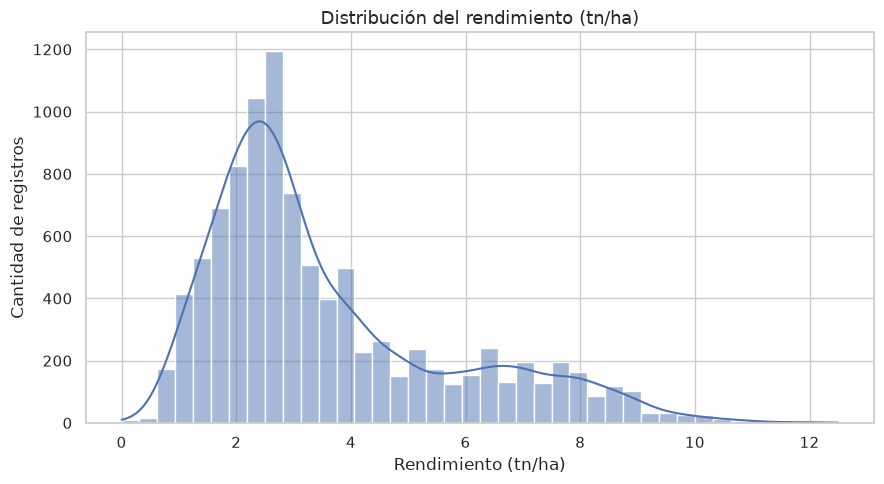

In [16]:
fig, ax = plt.subplots()
sns.histplot(silver_disco["rendimiento_tn_ha"], bins=40, kde=True, ax=ax)
ax.set_title("Distribución del rendimiento (tn/ha)")
ax.set_xlabel("Rendimiento (tn/ha)"); ax.set_ylabel("Cantidad de registros")
plt.tight_layout(); plt.show()

### Rendimiento por cultivo (boxplot)

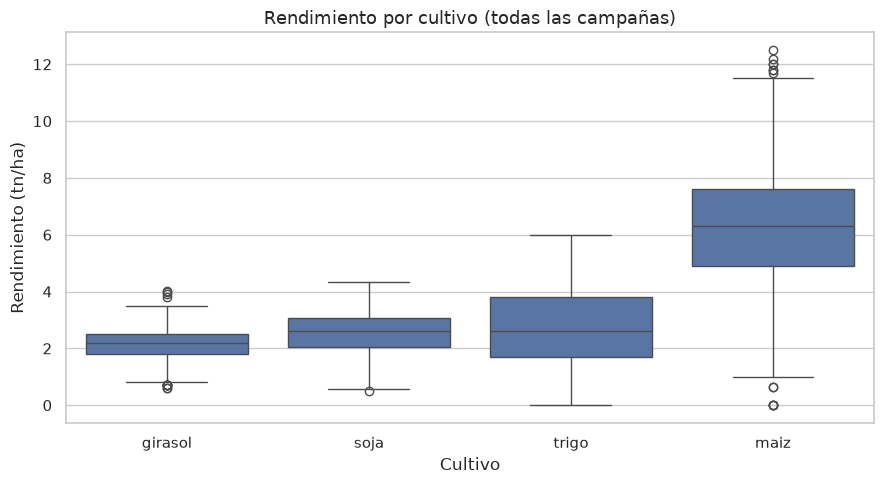

In [17]:
fig, ax = plt.subplots()
orden = silver_disco.groupby("cultivo")["rendimiento_tn_ha"].median().sort_values().index
sns.boxplot(data=silver_disco, x="cultivo", y="rendimiento_tn_ha", order=orden, ax=ax)
ax.set_title("Rendimiento por cultivo (todas las campañas)")
ax.set_xlabel("Cultivo"); ax.set_ylabel("Rendimiento (tn/ha)")
plt.tight_layout(); plt.show()

### Evolución del rendimiento por campaña (desde la capa Gold)

Acá se ve el valor de la data real: el bajón de rinde en campañas de **sequía**
(por ejemplo 2017/2018 y 2022/2023) aparece solo.

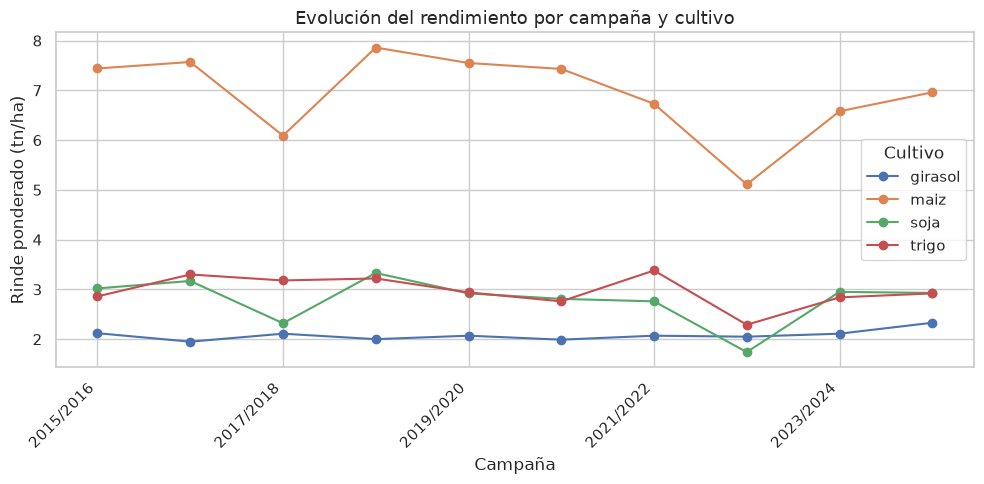

In [18]:
tabla_evol_disco = pd.read_csv(CURATED / "evolucion_rinde_por_campania.csv",
                              index_col="campania")
fig, ax = plt.subplots(figsize=(10, 5))
tabla_evol_disco.plot(marker="o", ax=ax)
ax.set_title("Evolución del rendimiento por campaña y cultivo")
ax.set_xlabel("Campaña"); ax.set_ylabel("Rinde ponderado (tn/ha)")
ax.legend(title="Cultivo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

### Producción total por provincia (barras, top 10)

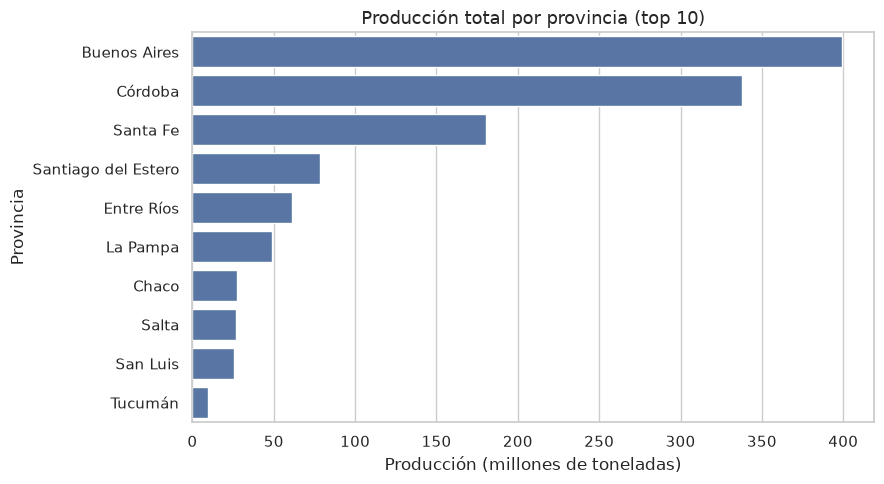

In [19]:
prod_prov = (silver_disco.groupby("provincia")["produccion_tn"].sum()
               .sort_values(ascending=False).head(10) / 1_000_000)
fig, ax = plt.subplots()
sns.barplot(x=prod_prov.values, y=prod_prov.index, ax=ax)
ax.set_title("Producción total por provincia (top 10)")
ax.set_xlabel("Producción (millones de toneladas)"); ax.set_ylabel("Provincia")
plt.tight_layout(); plt.show()

### Mapa de calor de correlaciones

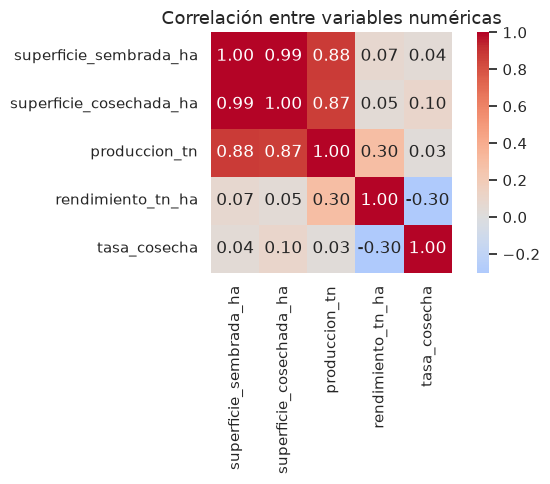

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlación entre variables numéricas")
plt.tight_layout(); plt.show()

## Preguntas analíticas y conclusiones

Cerramos respondiendo preguntas concretas con las capas que construimos.

In [20]:
# P1: ¿Qué cultivo produce más toneladas en total? (Gold)
top_cultivo = resumen_cultivo["produccion_total_tn"].idxmax()
print(f"P1 · Cultivo de mayor producción: {top_cultivo} "
      f"({resumen_cultivo.loc[top_cultivo, 'produccion_total_tn']/1e6:,.1f} M tn)")

# P2: ¿Qué provincia concentra más producción? (Silver)
prod_prov = silver_disco.groupby("provincia")["produccion_tn"].sum()
print(f"P2 · Provincia líder en producción: {prod_prov.idxmax()} "
      f"({prod_prov.max()/1e6:,.1f} M tn)")

# P3: ¿Cuál fue la peor campaña por rinde promedio? (Silver)
rinde_camp = (silver_disco.groupby("campania")
              .apply(lambda d: d["produccion_tn"].sum() / d["superficie_cosechada_ha"].sum(),
                     include_groups=False))
print(f"P3 · Peor campaña (menor rinde global): {rinde_camp.idxmin()} "
      f"({rinde_camp.min():.2f} tn/ha) | Mejor: {rinde_camp.idxmax()} ({rinde_camp.max():.2f} tn/ha)")

# P4: rinde ponderado por cultivo (Gold)
print("\nP4 · Rinde ponderado por cultivo (tn/ha):")
print(resumen_cultivo["rinde_ponderado_tn_ha"].sort_values(ascending=False))

P1 · Cultivo de mayor producción: maiz (518.2 M tn)
P2 · Provincia líder en producción: Buenos Aires (398.9 M tn)
P3 · Peor campaña (menor rinde global): 2022/2023 (2.76 tn/ha) | Mejor: 2018/2019 (4.27 tn/ha)

P4 · Rinde ponderado por cultivo (tn/ha):
cultivo
maiz       6.89
trigo      2.98
soja       2.82
girasol    2.09
Name: rinde_ponderado_tn_ha, dtype: float64


### Conclusiones

- Partimos de **datos reales y abiertos del MAGyP** y los llevamos por tres capas
  de calidad creciente —**unprocessed → processed → curated**— en un solo proceso
  reproducible.
- La limpieza con datos reales no es cosmética: si no **consolidábamos los
  cultivos** habríamos contado la soja dos veces, y si no **separábamos las
  pérdidas de cosecha** los promedios de rinde quedaban subestimados.
- Las series por campaña dejan ver fenómenos reales (caídas de rinde por sequía),
  algo que un dataset inventado no podría mostrar.

> **Para seguir practicando:** analizá la columna `tasa_cosecha` por campaña para
> medir años de pérdidas, sumá el precio internacional para estimar ingresos, o
> re-ejecutá el notebook entero y comprobá que el resultado es idéntico
> (idempotencia).